In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import scipy.io as io
import sys
from tqdm import tqdm
import gc

global_path = "/home/ids/edabier/HSU"
# global_path = "/home/edabier/Documents/Thèse/benchmark"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils
from src.utils import plots
from src.models import models
from src.models import foundation_models as rsfm

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttri

Using device: cuda:0


In [6]:
dataset = "urban"
data = io.loadmat(f"datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
A_init = utils.oneD_to_2d(A_flat)
H = Y_init.shape[-1]
Y_init = Y_init.unsqueeze(0)
A = A_init.unsqueeze(0)

if dataset == "urban4":
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/urban_wavelength.txt"
else:
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

fm, Y_up, new_H = rsfm.create_fm("DOFA", Y_init, n_features=1, use_cls=False, extend_cls=False, path=global_path, patch_size=16)
features = rsfm.get_dofa_features(fm, Y_up, wavelengths)
D = int(features.shape[0]/1)
alpha = int(features.shape[1]**0.5)
# unmixer = rsfm.Unmixing_from_features(D=D, alpha=alpha, B=B, c=c, n_features=1, use_cls=False)

Y_224, A_224 = rsfm.reshape_Y("DOFA", Y_init, new_H, A)

In [23]:
patch = 16
padding = patch//2
shift = 1
Y_padded = F.pad(Y_224, pad=(padding, padding, padding, padding), mode="reflect")

feature_map = torch.zeros(1, D, new_H, new_H, device=dev)

with torch.no_grad():
    for i in tqdm(range(0, 2*padding)):
        for j in range(0, 2*padding):

            n_crop = patch*(i//shift) + j//shift
            
            Y_crop = Y_padded[:, :, i:i+new_H, j:j+new_H]
            Y_crop = Y_crop.to(dev)
            _, features = rsfm.extract_f(fm, Y_crop, new_H, wavelengths, use_cls=False)

            features = features.reshape(1, D, alpha, alpha)
            feature_map[:,:, i::patch, j::patch] = features
            
            del features, Y_crop
            torch.cuda.synchronize()
            torch.cuda.empty_cache()
            gc.collect()
feature_map = (feature_map - feature_map.mean())/ (1e-8 + feature_map.std())

100%|██████████| 16/16 [01:01<00:00,  3.87s/it]


In [ ]:
patch = 16
padding = patch//2
shift = 1
x_new = torch.linspace(0, new_H - 1, new_H)
grid_y, grid_x = torch.meshgrid(x_new, x_new, indexing='ij')
grid = torch.stack((grid_x, grid_y), dim=-1).unsqueeze(0)
grid = grid / torch.tensor([(new_H - 1) / 2, (new_H - 1) / 2]) - 1

epochs, lr = 50, 0.002
optim_wrapper = dict(
    optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
    constructor='LayerDecayOptimizerConstructor_ViT',
    paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9))
    
model = rsfm.Unmixing_from_features2(D=D, alpha=alpha, H=new_H, B=B, c=c, n_features=1)
model.apply(model.weights_init)
model = models.init_decoder_weights(model, Y_224/Y_224.max(), c, is_unmixer=True, normalize=False)
model = model.to(dev)
optimizer = build_optim_wrapper(model, optim_wrapper)

n_xp = 1
E_hats_pad, A_hats_pad = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
sads_base, mses_base, sads_pad, mses_pad = [], [], [], []

Y_padded = F.pad(Y_224, pad=(padding, padding, padding, padding), mode="reflect")
feature_map = torch.zeros(1, D, new_H, new_H, device=dev)

with torch.no_grad():
    for i in tqdm(range(0, 2*padding)):
        for j in range(0, 2*padding):

            n_crop = patch*(i//shift) + j//shift
            
            Y_crop = Y_padded[:, :, i:i+new_H, j:j+new_H]
            Y_crop = Y_crop.to(dev)
            _, features = rsfm.extract_f(fm, Y_crop, new_H, wavelengths, use_cls=False)

            features = features.reshape(1, D, alpha, alpha)
            feature_map[:,:, i::patch, j::patch] = features
            
            del features, Y_crop
            torch.cuda.synchronize()
            torch.cuda.empty_cache()
            gc.collect()

for epoch in range(epochs):
    optimizer.zero_grad()
    feature_map_resampled = F.grid_sample(feature_map, grid, mode='bilinear', padding_mode='reflection', align_corners=True)
    E_hat, A_hat, Y_hat = model(feature_map_resampled)
    E_hat, A_hat, _ = utils.order_endmembers(E_init, E_hat, A_hat)
    A_hat = A_hat.unsqueeze(0)
    loss = model.loss(Y_224, Y_hat, A_hat, E_hat)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        constraints = models.weightConstraint()
        model.decoder.apply(constraints)
    
    del E_hat, A_hat, feature_map

    if epoch%(epochs//10)==0:
        print(f"Current epoch: {epoch}")

model.eval()
with torch.no_grad():    
    feature_map_resampled = F.grid_sample(feature_map, grid, mode='bilinear', padding_mode='reflection', align_corners=True)
    E_hat, A_hat, Y_hat = model(feature_map_resampled)
    E_hat, A_hat, _ = utils.order_endmembers(E_init, E_hat, A_hat)
    A_hat = A_hat.unsqueeze(0)
sad_pad, _, mse_pad = plots.compute_metrics_and_plot(E_hat, A_hat, A_224, E_init, normalize_E=True, normalize_A=True, return_results=True)#, plot_A=False, plot_E=False)
# sads_pad.append(sad_pad)
# mses_pad.append(mse_pad)

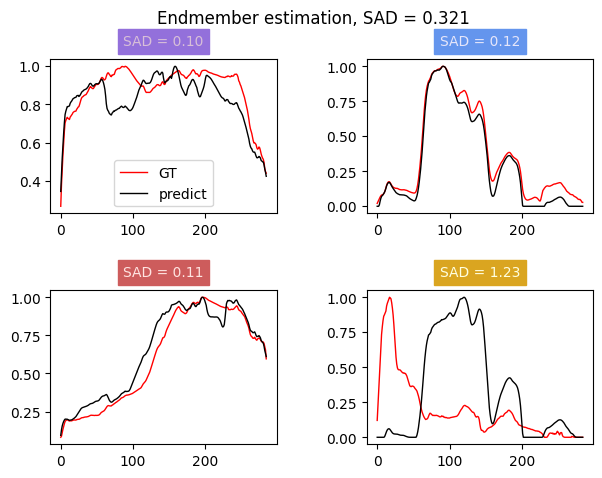

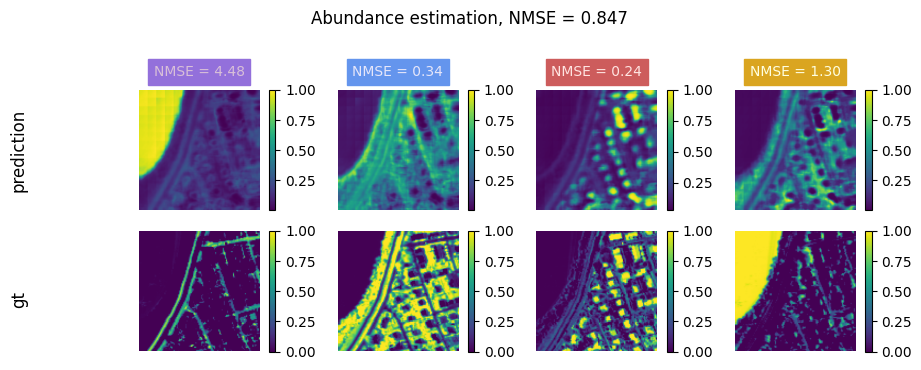

In [8]:
model.eval()
feature_map = torch.zeros(1, D, new_H, new_H, device=dev)
with torch.no_grad():
    for i in range(0, 2*padding):
        for j in range(0, 2*padding):

            Y_crop = Y_padded[:, :, i:i+new_H, j:j+new_H]
            Y_crop = Y_crop.to(dev)
            _, features = rsfm.extract_f(fm, Y_crop, new_H, wavelengths, use_cls=False)
            features = features.reshape(1, D, alpha, alpha)
            feature_map[:,:, i::patch, j::patch] = features
            
            del features, Y_crop
            torch.cuda.synchronize()
            torch.cuda.empty_cache()
            gc.collect()

    E_hat, A_hat, Y_hat = model(feature_map)
    E_hat, A_hat, _ = utils.order_endmembers(E_init, E_hat, A_hat)
    A_hat = A_hat.unsqueeze(0)
sad_pad, _, mse_pad = plots.compute_metrics_and_plot(E_hat, A_hat, A_224, E_init, normalize_E=True, normalize_A=True, return_results=True)

In [6]:
# resampling A_hat (1, c, new_H, new_H)
x_new = torch.linspace(0, new_H - 1, new_H)
grid_y, grid_x = torch.meshgrid(x_new, x_new, indexing='ij')
grid = torch.stack((grid_x, grid_y), dim=-1).unsqueeze(0)  # Shape: (1, H, W, 2)

# Normalize grid coordinates to [-1, 1] (required by grid_sample)
grid = grid / torch.tensor([(new_H - 1) / 2, (new_H - 1) / 2]) - 1

A_interpolated = F.grid_sample(A_hat, grid, mode='bilinear', padding_mode='reflection', align_corners=True)

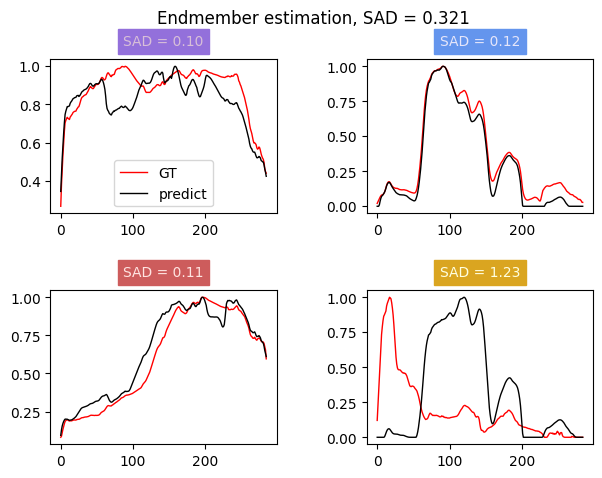

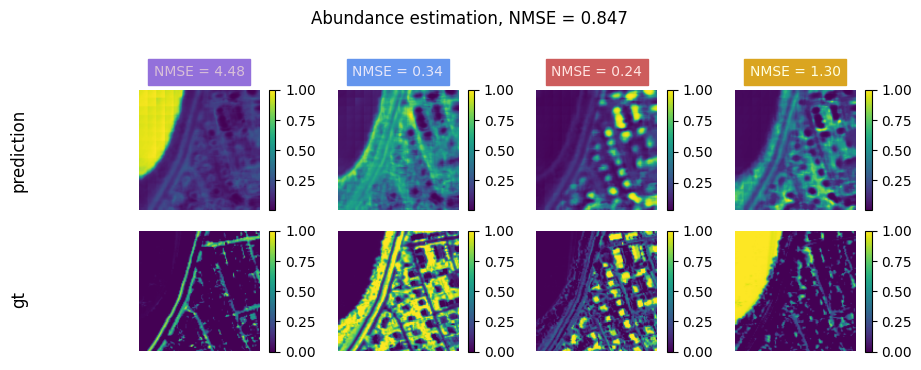

In [9]:
# A_hat = A_hat/ A_hat.amax(dim=(1,2), keepdim=True)
# A_gt = A_224/ A_224.amax(dim=(1,2), keepdim=True)
sad_pad, _, mse_pad = plots.compute_metrics_and_plot(E_hat, A_interpolated, A_224, E_init, normalize_E=True, normalize_A=True, return_results=True)